# Notebook 1 — Chuẩn bị dữ liệu (v2)

Pipeline tự thu thập + EDA + tiền xử lý cho bài toán phân loại **fresh vs rotten**.

## Mục lục
1. Setup môi trường
2. Crawl ảnh (chỉ chạy 1 lần, mất 30-60 phút)
3. Kiểm tra dataset thô
4. **EDA — Phân tích khám phá dữ liệu** (7 phân tích)
5. Tiền xử lý + split train/valid/test
6. Demo augmentation


## 1. Setup môi trường

In [1]:
# Set CWD về thư mục project (notebook nằm trong notebook/)
import os, sys
from pathlib import Path

ROOT = Path('..').resolve() if Path.cwd().name == 'notebook' else Path.cwd()
if Path.cwd().name == 'notebook':
    os.chdir(ROOT)
sys.path.insert(0, str(Path.cwd()))

print('CWD     :', Path.cwd())
print('Python  :', sys.version.split()[0])

# Common imports dùng xuyên suốt notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
})

RAW = Path('dataset/raw')
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
CLASSES = ['fresh', 'rotten']
CLASS_COLOR = {'fresh': '#2E7D32', 'rotten': '#C62828'}

print('Setup OK')


CWD     : D:\Khoa học dữ liệu\project
Python  : 3.12.3


Setup OK


C:\Users\nvant\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Crawl ảnh (tuỳ chọn — bỏ qua nếu đã có dataset)

Crawl từ Bing + Baidu + DuckDuckGo. **Bỏ comment dòng dưới** nếu chưa có data.

In [2]:
# Bỏ comment để chạy crawl. Mất 30-60 phút lần đầu.
# !python crawler/crawl_images.py --target 12000 --engines bing,baidu,duckduckgo
print('Skip crawl (đã có dataset/raw)')


Skip crawl (đã có dataset/raw)


## 3. Kiểm tra dataset thô

In [3]:
# 3.1 Đếm số ảnh theo class
assert RAW.exists(), 'Chưa có dataset/raw — chạy cell crawl trước'

stats = {d.name: sum(1 for f in d.iterdir() if f.is_file())
         for d in RAW.iterdir() if d.is_dir()}
print('Số ảnh từng class:')
for k, v in stats.items():
    print(f'  {k:<8s}: {v:,}')
print(f'  {"TONG":<8s}: {sum(stats.values()):,}')


Số ảnh từng class:
  fresh   : 6,000
  rotten  : 6,000
  TONG    : 12,000


In [4]:
# 3.2 Quét toàn bộ ảnh: kích thước, lỗi, keyword
import re

broken, small_imgs, sizes, keywords = [], [], [], Counter()
for cls_dir in sorted(d for d in RAW.iterdir() if d.is_dir()):
    for f in tqdm(list(cls_dir.iterdir()), desc=cls_dir.name):
        try:
            with Image.open(f) as im:
                w, h = im.size
                sizes.append((w, h, cls_dir.name))
                if min(w, h) < 64:
                    small_imgs.append(f)
        except (UnidentifiedImageError, OSError):
            broken.append(f)
        m = re.match(r'(.+?)_\d+$', f.stem)
        kw = m.group(1) if m else f.stem
        keywords[kw] += 1

print(f'\nTổng ảnh hợp lệ : {len(sizes):,}')
print(f'Ảnh hỏng        : {len(broken)}')
print(f'Ảnh < 64px      : {len(small_imgs)}')
print(f'Số keyword khác : {len(keywords)}')
print(f'\nTop 10 keyword nhiều ảnh nhất:')
for kw, n in keywords.most_common(10):
    print(f'  {kw:<35s}: {n:,}')


fresh:   0%|          | 0/6000 [00:00<?, ?it/s]

fresh:   5%|▍         | 278/6000 [00:00<00:02, 2766.02it/s]

fresh:  10%|▉         | 575/6000 [00:00<00:01, 2870.87it/s]

fresh:  14%|█▍        | 863/6000 [00:00<00:01, 2596.41it/s]

fresh:  19%|█▉        | 1127/6000 [00:00<00:01, 2604.26it/s]

...

rotten:  91%|█████████ | 5455/6000 [00:02<00:00, 2703.57it/s]

rotten:  95%|█████████▌| 5726/6000 [00:02<00:00, 2684.43it/s]

rotten: 100%|█████████▉| 5995/6000 [00:02<00:00, 2685.64it/s]

rotten: 100%|██████████| 6000/6000 [00:02<00:00, 2543.34it/s]


Tổng ảnh hợp lệ : 12,000
Ảnh hỏng        : 0
Ảnh < 64px      : 0
Số keyword khác : 2348

Top 10 keyword nhiều ảnh nhất:
  web_extra                          : 4,314
  fresh_vegetables_on_table          : 188
  fresh_broccoli                     : 138
  fresh_carrot                       : 136
  fresh_mango                        : 135
  fresh_grape_fruit                  : 133
  fresh_orange_fruit                 : 130
  rotten_apple                       : 126
  fresh_bell_pepper                  : 122
  fresh_tomato                       : 121


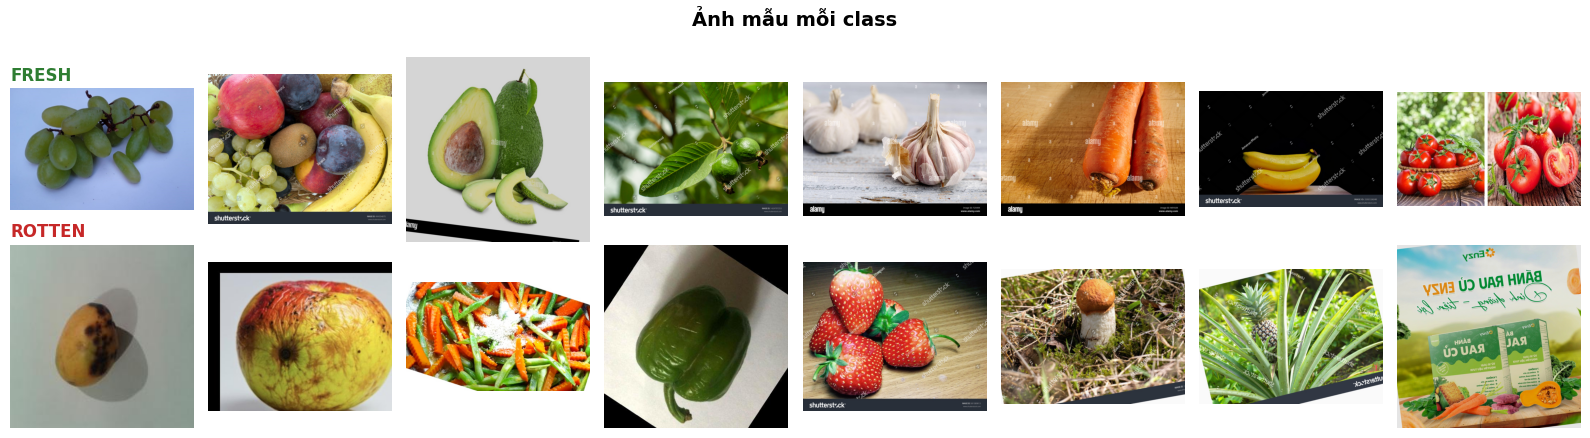

In [5]:
# 3.3 Sample grid: 8 ảnh fresh + 8 ảnh rotten random
import random
random.seed(42)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for row, cls in enumerate(CLASSES):
    files = random.sample([f for f in (RAW / cls).iterdir() if f.is_file()], 8)
    for col, f in enumerate(files):
        try:
            axes[row, col].imshow(Image.open(f))
        except Exception:
            pass
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls.upper(), loc='left', fontweight='bold',
                                     fontsize=12, color=CLASS_COLOR[cls])
plt.suptitle('Ảnh mẫu mỗi class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_sample_grid.png', bbox_inches='tight')
plt.show()


## 4. EDA — Phân tích khám phá dữ liệu

7 câu hỏi cần trả lời trước khi train:

1. Phân bố class có cân bằng?
2. Phân bố nguồn (crawl tự thu thập / augmentation / web extra)?
3. Kích thước ảnh phân bố ra sao?
4. Aspect ratio (W/H) phân bố thế nào?
5. Format file đa dạng cỡ nào?
6. Màu sắc trung bình fresh vs rotten có khác?
7. Top keyword nhiều ảnh nhất?

Tất cả output cũng được lưu vào `results/eda_*.png` để chèn vào báo cáo.

In [6]:
# 4.0 Build inventory — quét metadata 1 lần, dùng cho mọi EDA bên dưới
import json

print('Quét toàn bộ dataset/raw để build inventory...')
records = []
for cls in CLASSES:
    cls_dir = RAW / cls
    for f in tqdm(list(cls_dir.iterdir()), desc=cls):
        if not f.is_file():
            continue
        # Phân loại nguồn theo prefix tên file
        stem = f.stem
        if stem.startswith('aug_'):
            source = 'augmentation'
        elif stem.startswith('web_extra_'):
            source = 'web_extra'
        else:
            source = 'crawl'
        try:
            with Image.open(f) as im:
                w, h = im.size
                fmt = (im.format or 'UNKNOWN').upper()
        except (UnidentifiedImageError, OSError):
            continue
        records.append({
            'class': cls, 'file': f.name, 'source': source,
            'width': w, 'height': h, 'format': fmt,
            'aspect': round(w / h, 3),
            'size_kb': f.stat().st_size // 1024,
        })

df = pd.DataFrame(records)
df.to_csv(RESULTS / 'eda_inventory.csv', index=False, encoding='utf-8')
print(f'Total: {len(df):,} ảnh hợp lệ → đã lưu eda_inventory.csv')
df.head()


Quét toàn bộ dataset/raw để build inventory...


fresh:   0%|          | 0/6000 [00:00<?, ?it/s]

fresh:   4%|▍         | 248/6000 [00:00<00:02, 2464.50it/s]

fresh:   8%|▊         | 508/6000 [00:00<00:02, 2540.22it/s]

fresh:  13%|█▎        | 763/6000 [00:00<00:02, 2543.07it/s]

...

rotten:  92%|█████████▏| 5512/6000 [00:02<00:00, 2545.02it/s]

rotten:  96%|█████████▌| 5772/6000 [00:02<00:00, 2557.45it/s]

rotten: 100%|██████████| 6000/6000 [00:02<00:00, 2462.26it/s]

Total: 12,000 ảnh hợp lệ → đã lưu eda_inventory.csv


,class,file,source,width,height,format,aspect,size_kb
0,fresh,aug_ca_chua_tuoi_00001_01.jpg,augmentation,1080,1080,JPEG,1.000,115
1,fresh,aug_ca_chua_tuoi_00002_01.jpg,augmentation,1080,1080,JPEG,1.000,150
2,fresh,aug_ca_chua_tuoi_00003_01.jpg,augmentation,600,400,JPEG,1.500,53
3,fresh,aug_ca_chua_tuoi_00004_01.jpg,augmentation,660,440,JPEG,1.500,62
4,fresh,aug_ca_chua_tuoi_00005_01.jpg,augmentation,1280,720,JPEG,1.778,164


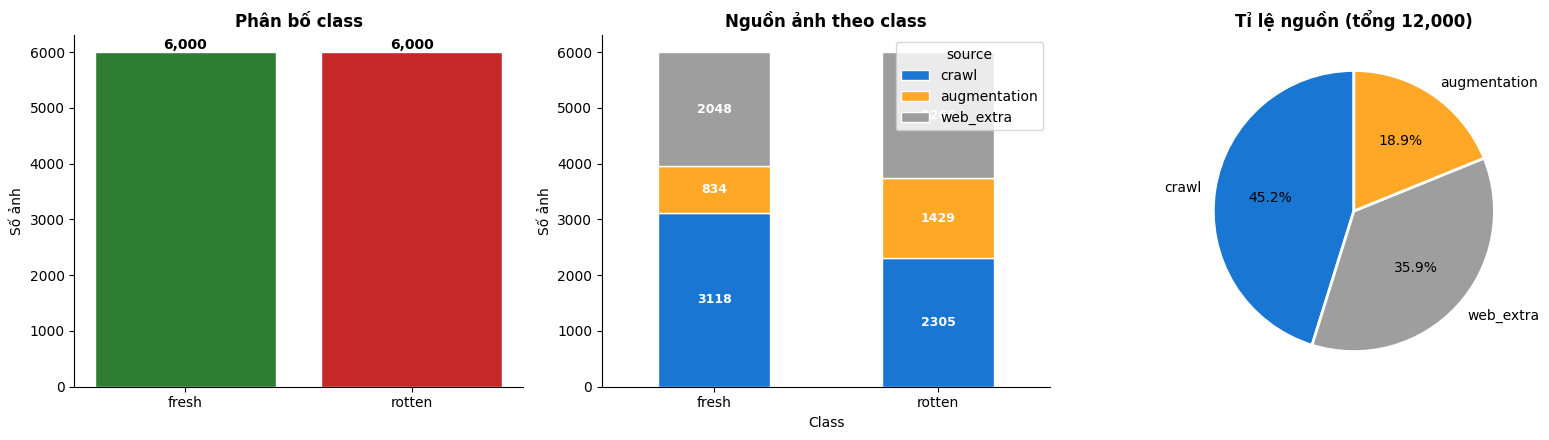

Pivot nguồn × class:
source  augmentation  crawl  web_extra
class                                 
fresh            834   3118       2048
rotten          1429   2305       2266


In [7]:
# 4.1 EDA: Phân bố CLASS + NGUỒN ẢNH (câu hỏi 1 + 2)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Subplot A: bar chart class
class_counts = df.groupby('class').size()
axes[0].bar(class_counts.index, class_counts.values,
            color=[CLASS_COLOR[c] for c in class_counts.index],
            edgecolor='white')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Phân bố class', fontweight='bold')
axes[0].set_ylabel('Số ảnh')

# Subplot B: stacked bar — nguồn theo class
pivot = df.groupby(['class', 'source']).size().unstack(fill_value=0)
sources_ordered = [s for s in ['crawl', 'augmentation', 'web_extra'] if s in pivot.columns]
pivot[sources_ordered].plot(kind='bar', stacked=True, ax=axes[1],
    color=['#1976D2', '#FFA726', '#9E9E9E'][:len(sources_ordered)],
    edgecolor='white')
axes[1].set_title('Nguồn ảnh theo class', fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Số ảnh')
axes[1].set_xticklabels(pivot.index, rotation=0)
for c in axes[1].containers:
    axes[1].bar_label(c, label_type='center', fontsize=9, color='white',
                      fontweight='bold')

# Subplot C: pie tổng nguồn
src_total = df['source'].value_counts()
src_color_map = {'crawl': '#1976D2', 'augmentation': '#FFA726', 'web_extra': '#9E9E9E'}
axes[2].pie(src_total, labels=src_total.index,
            colors=[src_color_map.get(s, '#666666') for s in src_total.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title(f'Tỉ lệ nguồn (tổng {len(df):,})', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS / 'eda_source_distribution.png', bbox_inches='tight')
plt.show()
print('Pivot nguồn × class:')
print(pivot)


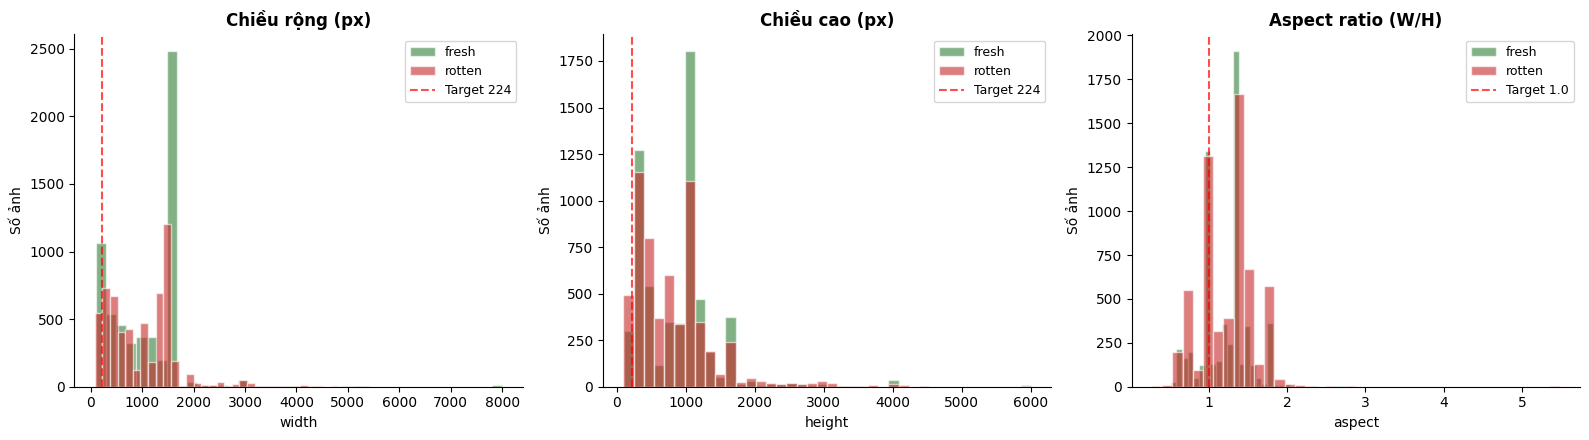

Thống kê kích thước:
          width    height    aspect   size_kb
count  12000.00  12000.00  12000.00  12000.00
mean    1033.21    857.20      1.23    396.09
std      683.98    598.28      0.32    660.73
min       80.00     97.00      0.27      1.00
25%      432.75    360.00      1.00     24.00
50%     1060.00    846.00      1.33    122.00
75%     1500.00   1101.00      1.37    471.00
max     8000.00   6000.00      5.48  13582.00


In [8]:
# 4.2 EDA: Kích thước + aspect ratio (câu hỏi 3 + 4)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, title, target in zip(
    axes,
    ['width', 'height', 'aspect'],
    ['Chiều rộng (px)', 'Chiều cao (px)', 'Aspect ratio (W/H)'],
    [224, 224, 1.0],
):
    for cls in CLASSES:
        ax.hist(df[df['class'] == cls][col], bins=40, alpha=0.6,
                label=cls, color=CLASS_COLOR[cls], edgecolor='white')
    ax.axvline(target, color='red', ls='--', alpha=0.7, label=f'Target {target}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Số ảnh')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / 'eda_size_distribution.png', bbox_inches='tight')
plt.show()

print('Thống kê kích thước:')
print(df[['width', 'height', 'aspect', 'size_kb']].describe().round(2))


Format theo class:
format  JPEG  PNG  WEBP
class                  
fresh   5646   85   269
rotten  5549  135   316


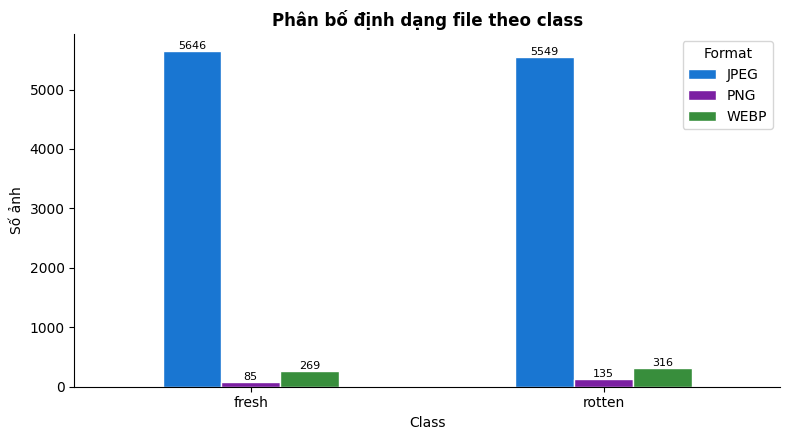


Nhận xét: ảnh sẽ được chuẩn hoá về JPEG khi resize.


In [9]:
# 4.3 EDA: Phân bố format file (câu hỏi 5)
fmt_count = df.groupby(['class', 'format']).size().unstack(fill_value=0)
print('Format theo class:')
print(fmt_count)

fig, ax = plt.subplots(figsize=(8, 4.5))
fmt_count.plot(kind='bar', ax=ax, edgecolor='white',
               color=['#1976D2', '#7B1FA2', '#388E3C', '#F57C00', '#5D4037'])
ax.set_title('Phân bố định dạng file theo class', fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Số ảnh')
ax.set_xticklabels(fmt_count.index, rotation=0)
ax.legend(title='Format', loc='best')
for c in ax.containers:
    ax.bar_label(c, label_type='edge', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_format_distribution.png', bbox_inches='tight')
plt.show()
print('\nNhận xét: ảnh sẽ được chuẩn hoá về JPEG khi resize.')


color fresh:   0%|          | 0/500 [00:00<?, ?it/s]

color fresh:   2%|▏         | 11/500 [00:00<00:04, 103.03it/s]

color fresh:   4%|▍         | 22/500 [00:00<00:04, 96.80it/s] 

color fresh:   6%|▋         | 32/500 [00:00<00:05, 87.32it/s]

color fresh:   8%|▊         | 41/500 [00:00<00:05, 83.64it/s]

...

color rotten:  90%|█████████ | 452/500 [00:04<00:00, 103.52it/s]

color rotten:  93%|█████████▎| 463/500 [00:05<00:00, 95.28it/s] 

color rotten:  95%|█████████▍| 473/500 [00:05<00:00, 84.61it/s]

color rotten:  98%|█████████▊| 491/500 [00:05<00:00, 106.66it/s]

color rotten: 100%|██████████| 500/500 [00:05<00:00, 93.01it/s] 

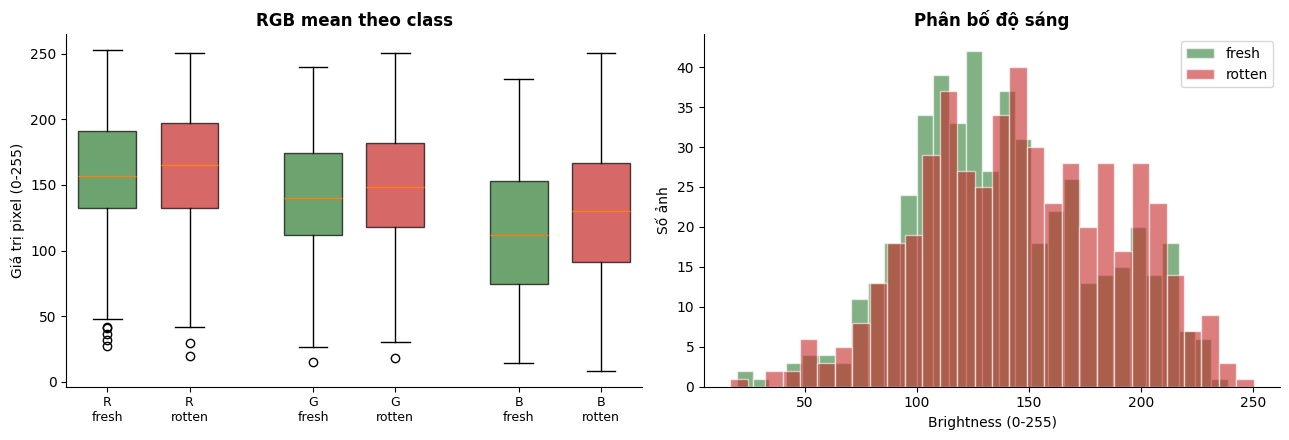

Mean RGB per class:
        R_mean  G_mean  B_mean  brightness
class                                     
fresh    159.5   143.0   114.3       138.9
rotten   162.5   149.1   128.8       146.8


In [10]:
# 4.4 EDA: Color stats — RGB mean fresh vs rotten (câu hỏi 6)
import random
random.seed(42)

color_stats = []
for cls in CLASSES:
    files = list((RAW / cls).iterdir())
    sample = random.sample(files, min(500, len(files)))
    for f in tqdm(sample, desc=f'color {cls}'):
        try:
            with Image.open(f) as im:
                im = im.convert('RGB').resize((64, 64))
                arr = np.asarray(im)
                color_stats.append({
                    'class': cls,
                    'R_mean': arr[..., 0].mean(),
                    'G_mean': arr[..., 1].mean(),
                    'B_mean': arr[..., 2].mean(),
                    'brightness': arr.mean(),
                })
        except (UnidentifiedImageError, OSError):
            continue

df_color = pd.DataFrame(color_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Boxplot RGB
data, positions, labels, box_colors = [], [], [], []
i = 0
for ch in ['R_mean', 'G_mean', 'B_mean']:
    for cls in CLASSES:
        data.append(df_color[df_color['class'] == cls][ch].values)
        positions.append(i); i += 1
        labels.append(f'{ch[0]}\n{cls}')
        box_colors.append(CLASS_COLOR[cls])
    i += 0.5
bp = axes[0].boxplot(data, positions=positions, patch_artist=True, widths=0.7)
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_xticks(positions); axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_title('RGB mean theo class', fontweight='bold')
axes[0].set_ylabel('Giá trị pixel (0-255)')

# Brightness
for cls in CLASSES:
    axes[1].hist(df_color[df_color['class'] == cls]['brightness'],
                 bins=30, alpha=0.6, label=cls,
                 color=CLASS_COLOR[cls], edgecolor='white')
axes[1].set_title('Phân bố độ sáng', fontweight='bold')
axes[1].set_xlabel('Brightness (0-255)'); axes[1].set_ylabel('Số ảnh')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'eda_color_stats.png', bbox_inches='tight')
plt.show()

print('Mean RGB per class:')
print(df_color.groupby('class')[['R_mean', 'G_mean', 'B_mean', 'brightness']]
      .mean().round(1))


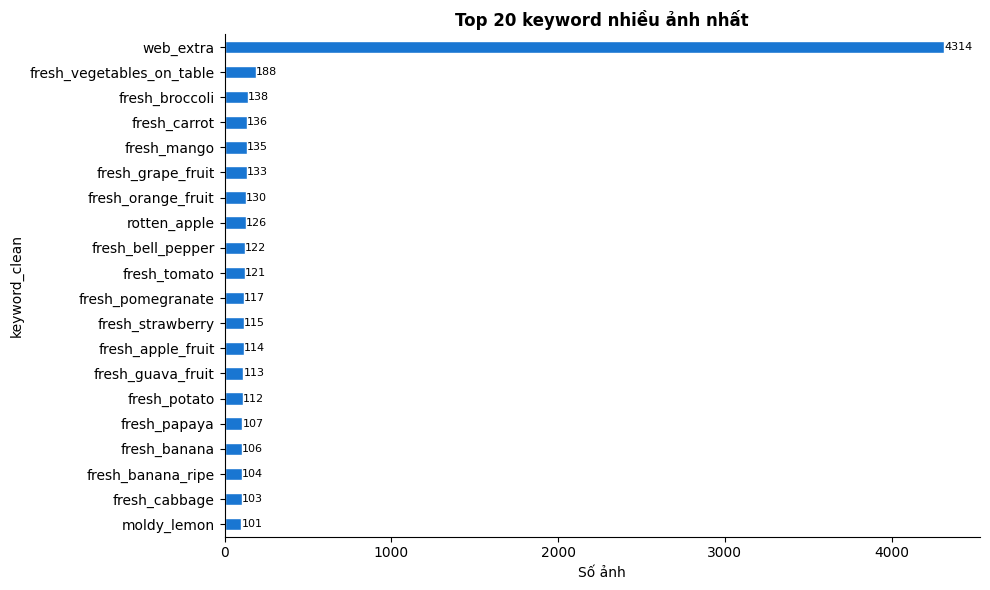

TỔNG KẾT EDA (đã lưu eda_summary.json):
  total_images: 12000
  by_class: {'fresh': 6000, 'rotten': 6000}
  by_source: {'augmentation': 2263, 'crawl': 5423, 'web_extra': 4314}
  by_format: {'JPEG': 11195, 'PNG': 220, 'WEBP': 585}
  size_stats: {'width_mean': 1033.2118333333333, 'height_mean': 857.20325, 'aspect_mean': 1.2310271666666668, 'aspect_median': 1.333}
  unique_keywords: 2348


In [11]:
# 4.5 EDA: Top keyword + summary JSON (câu hỏi 7)
import re as _re

df['keyword'] = df['file'].apply(lambda x: _re.sub(r'_\d+(\.[a-z]+)?$', '', Path(x).stem))
df['keyword_clean'] = (df['keyword']
    .str.replace(r'^aug_', '', regex=True)
    .str.replace(r'^web_extra_\d*', 'web_extra', regex=True))

top_kw = df.groupby('keyword_clean').size().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_kw.plot(kind='barh', ax=ax, color='#1976D2', edgecolor='white')
ax.set_title('Top 20 keyword nhiều ảnh nhất', fontweight='bold')
ax.set_xlabel('Số ảnh'); ax.invert_yaxis()
for c in ax.containers:
    ax.bar_label(c, label_type='edge', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_top_keywords.png', bbox_inches='tight')
plt.show()

# Summary JSON cho báo cáo
summary = {
    'total_images': int(len(df)),
    'by_class': df.groupby('class').size().to_dict(),
    'by_source': df.groupby('source').size().to_dict(),
    'by_format': df.groupby('format').size().to_dict(),
    'size_stats': {
        'width_mean': float(df['width'].mean()),
        'height_mean': float(df['height'].mean()),
        'aspect_mean': float(df['aspect'].mean()),
        'aspect_median': float(df['aspect'].median()),
    },
    'unique_keywords': int(df['keyword_clean'].nunique()),
}
(RESULTS / 'eda_summary.json').write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print('TỔNG KẾT EDA (đã lưu eda_summary.json):')
for k, v in summary.items():
    print(f'  {k}: {v}')


## 5. Tiền xử lý + split train/valid/test

Resize 224x224, normalize, loại trùng/lỗi, chia 70/15/15.

In [12]:
# Bỏ comment để chạy. Mất ~5 phút cho 12k ảnh.
# !python preprocessing/preprocess.py --src dataset/raw --dst dataset --img-size 224
print('Skip preprocess (chạy khi sẵn sàng)')


Skip preprocess (chạy khi sẵn sàng)


In [13]:
# Sau khi chạy preprocess: kiểm tra phân bố train/valid/test
split_stats = {}
for split in ('train', 'valid', 'test'):
    sd = Path(f'dataset/{split}')
    if not sd.exists():
        continue
    split_stats[split] = {c.name: sum(1 for _ in c.iterdir())
                          for c in sd.iterdir() if c.is_dir()}

if split_stats:
    df_split = pd.DataFrame(split_stats).fillna(0).astype(int)
    print('Phân bố sau split:')
    print(df_split)
    print(f'\nTỔNG: {df_split.values.sum():,} ảnh')

    ax = df_split.plot.bar(figsize=(8, 4),
        color={'train': '#1976D2', 'valid': '#FFA726', 'test': '#7B1FA2'},
        edgecolor='white')
    ax.set_title('Phân bố train / valid / test', fontweight='bold')
    ax.set_ylabel('Số ảnh'); ax.set_xlabel('Class')
    ax.set_xticklabels(df_split.index, rotation=0)
    for c in ax.containers:
        ax.bar_label(c, label_type='edge', fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS / 'eda_split_distribution.png', bbox_inches='tight')
    plt.show()
else:
    print('Chưa có dataset/{train,valid,test}. Chạy cell preprocess ở trên trước.')


Chưa có dataset/{train,valid,test}. Chạy cell preprocess ở trên trước.


## 6. Demo augmentation

In [14]:
# Cần dataset/train tồn tại (sau preprocess). Nếu chưa có thì skip.
if Path('dataset/train').exists():
    from preprocessing.augmentation import build_train_generator
    gen = build_train_generator(Path('dataset/train'), img_size=224, batch_size=1)
    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
    for ax in axes.ravel():
        x, _ = next(gen)
        ax.imshow(x[0]); ax.axis('off')
    plt.suptitle('8 phiên bản sau augmentation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'eda_augmentation_demo.png', bbox_inches='tight')
    plt.show()
else:
    print('Chưa có dataset/train. Chạy cell preprocess trước.')


Chưa có dataset/train. Chạy cell preprocess trước.


## Hoàn thành chuẩn bị

Sau khi chạy hết notebook này, sẽ có:

- `dataset/raw/{fresh,rotten}/` — ảnh thô đã crawl
- `dataset/{train,valid,test}/{fresh,rotten}/` — đã resize 224, split 70/15/15
- `results/eda_*.png` — 6 biểu đồ EDA
- `results/eda_inventory.csv` — bảng metadata 12k ảnh
- `results/eda_summary.json` — số liệu tổng kết

**Bước tiếp theo**: chạy notebook `02_train_and_evaluate.ipynb` để train model.
